/var/folders/h3/gxsg9l7j7yb4ks48250kxs900000gn/T/ipykernel_92152/2295993652.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(symbol, start, end)
[*********************100%***********************]  1 of 1 completed


sigma: 0.019010442183268694 mu: 0.0007047431330112087


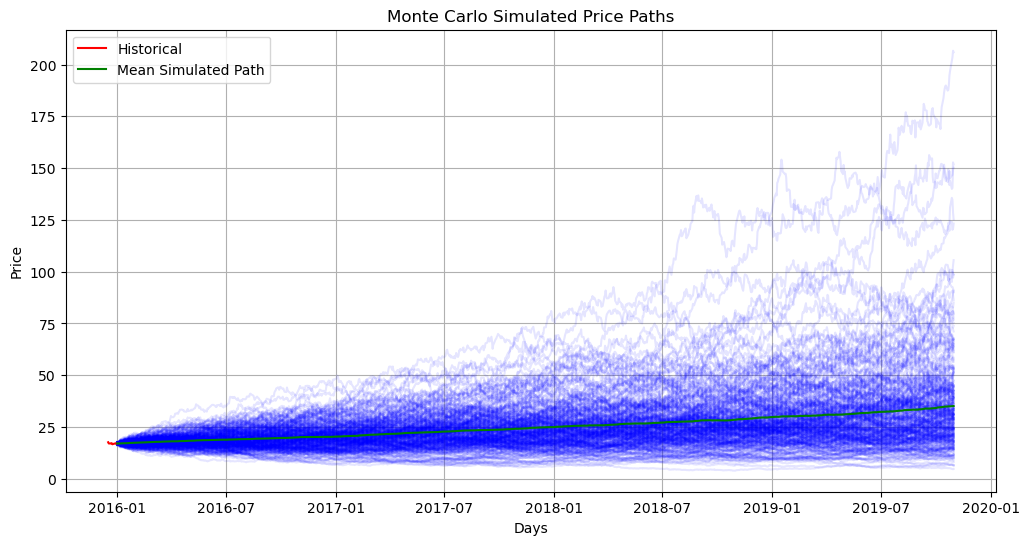

mean start price:  17.03516392895221
mean end price:  35.116372506535
No. sells: 22572
No. buys: 60102
mean trading profit:  1023.6400112858217
holding profit:  1383.890729373815
positive dif:  -360.2507180879933


In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random


start = "2005-01-01"
end = "2016-01-01"
n_days = 1000
n_paths = 302
symbol = "COKE"
close = f"Close_{symbol}"
raw_data = yf.download(symbol, start, end)
raw_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in raw_data.columns]
raw_data['MA10'] = raw_data[close].rolling(window=10).mean()
raw_data['MA50'] = raw_data[close].rolling(window=50).mean()
data = raw_data.dropna(subset=[close, 'MA10', 'MA50']).copy()

data['returns'] = data[close].pct_change().dropna()
mu = data['returns'].mean()
sigma = data['returns'].std()
print("sigma:", sigma, "mu:", mu)


def simulate_price_path(S0, mu, sigma, n_days, n_paths):
    r = np.random.normal(mu, sigma, (n_days, n_paths))
    sim_prices = S0 * np.cumprod(1 + r, axis=0)
    return sim_prices

sim_paths = simulate_price_path(data[close].iloc[-1], mu, sigma, n_days, n_paths)
last_date = data.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_days)
sim_df = pd.DataFrame(sim_paths, index=future_dates)

mean_path = sim_df.mean(axis=1)
plt.figure(figsize=(12,6))
plt.plot(sim_df, color='blue', alpha=0.1)
plt.plot(data[close].iloc[-10:], color='red', label='Historical')
plt.plot(mean_path, color='green', label='Mean Simulated Path')
plt.xlabel("Days")
plt.ylabel("Price")
plt.title("Monte Carlo Simulated Price Paths")
plt.grid(True)
plt.legend()
plt.show()

#predict mean hast changed much, look at next price, update mean partially based on it (psrtially depends on unc in mean and noise)
#deviation = P_t-kalman mean, normalise by volatility z score, sell/buy based on z score.

def kalman_filter_mean_vectorized(prices, q, r): #look to vary r 

    P = np.ones(prices.shape)  # stores uncertainty. ones makes an array filled with  ones
    mu_est = np.zeros(prices.shape) # stores estimated dynamic mean for each path at each step. np.zeros makes array of 0's, shape = tuple
    mu_est[0, :] = prices.iloc[0, :]
    
    price_array = prices.values #.values turns df to array 
    T, N = price_array.shape #converts df to array as faster,.shape gives tuple of shape 
    
    for t in range(1, T): #so only 1 loop for all of the df
        mu_pred = mu_est[t-1, :] #predicted mean is prev mean  
        P_pred = P[t-1, :] + q #predicted unc increases by q 
        K = P_pred / (P_pred + r.iloc[t, :].values) #k determines how much the new observation alters the mean estimate, 
        mu_est[t, :] = mu_pred + K * (price_array[t, :] - mu_pred) #update new mean using new estimate price. vec bc updates all paths 
        P[t, :] = (1 - K) * P_pred #update new unc after new price 
    
    return pd.DataFrame(mu_est, index=prices.index, columns=prices.columns)#array back to df

r_t = sim_df.ewm(alpha=0.2, adjust=False).std() ** 2
kalman_mean = kalman_filter_mean_vectorized(sim_df, 1e-5, r_t) #shape of sim_df, contains time varying mean 
kalman_std = sim_df.ewm(alpha=0.2, adjust=False).std()  # keep volatility normalization
z_score_kf = (sim_df - kalman_mean) / kalman_std


buy_signal_kf = (z_score_kf < -1.5)
sell_signal_kf = (z_score_kf > 1.5) & (~buy_signal_kf)


position_kf = pd.DataFrame(np.nan, index=sim_df.index, columns=sim_df.columns)
position_kf[buy_signal_kf] = sim_df[buy_signal_kf]
position_kf[sell_signal_kf] = sim_df[sell_signal_kf]

raw_trades_kf = buy_signal_kf.astype(int) - sell_signal_kf.astype(int)
inventory_kf = raw_trades_kf.cumsum()
valid_sells_kf = inventory_kf > 0
adj_sell_signal_kf = sell_signal_kf & valid_sells_kf


buy_prices_kf = sim_df.where(buy_signal_kf)
sell_prices_kf = sim_df.where(adj_sell_signal_kf)

first_prices = sim_df.iloc[0, :]
last_prices = sim_df.iloc[-1, :]
gen_profit = (last_prices - first_prices)*buy_prices_kf.count()
no_buy = buy_prices_kf.count()
no_sell = sell_prices_kf.count()
no_dif =  no_buy - no_sell 
mean_gen_profit = (gen_profit.mean())

sell_sum = sell_prices_kf.sum()
buy_sum = buy_prices_kf.sum()
prof = (sell_sum - buy_sum) + (last_prices * no_dif)
mean_prof = prof.mean()

print('mean start price: ', float(first_prices.mean()))
print('mean end price: ', float(last_prices.mean()))
print(f'No. sells: {no_sell.sum()}')
print(f'No. buys: {no_buy.sum()}')
print('mean trading profit: ', mean_prof)
print('holding profit: ', mean_gen_profit)
print('positive dif: ', (mean_prof - mean_gen_profit))
